In [ ]:
!pip install chart_studio
!pip install plotly
!pip install opensearch-py-ml
!pip install pandas==2.0.3
!pip install matplotlib

In [21]:
ABUNDANCE_FILENAME = 'TMT_4plex/abundance_gene_MD.tsv'
ANNOTATION_FILENAME = 'TMT_4plex/experiment_annotation.tsv'
INDEX_NAME = '656a505afdd014a1f3e3fddd_63ddc9ce1e740e0020c39928'
USER_QUERY = "cadd > 15 (exonic || (nearestTss.refSeq.dist > -1000 && nearestTss.refSeq.dist < 1000))"

from opensearchpy import OpenSearch

from bystro.proteomics.annotation_interface import OPENSEARCH_CONFIG, get_annotation_result_from_query, join_annotation_result_to_proteomics_dataset
from bystro.proteomics.fragpipe_tandem_mass_tag import TandemMassTagDataset, load_tandem_mass_tag_dataset
from bystro.search.utils.opensearch import gather_opensearch_args

client = OpenSearch(**OPENSEARCH_CONFIG)

In [22]:
query_result_df = get_annotation_result_from_query(
    USER_QUERY, INDEX_NAME, client  # type: ignore
)

def fake_samples(x):
    if x == '1805':
        return 'CPT0079380003' # data
    if x == '1847': 
        return 'CPT0088920001' # mom 
    if x == '4805':
        return 'CPT0014450004' # child 
        

query_result_df['sample_id'] = query_result_df['sample_id'].apply(fake_samples)
query_result_df.head(5)

/home/ubuntu/bystro/python/python/bystro/proteomics/annotation_interface.py:214: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  samples_genes_dosages_df = pd.concat(


,sample_id,chrom,pos,ref,alt,transcript,gene_name,exonic_allele_function,dosage,cadd,caddIndel,gnomad_genomes_af,gnomad_exomes_af
0,CPT0079380003,chr17,7907189,C,T,NM_000180,GUCY2D,synonymous,1.0,11.8,NaN,0.112824,0.117983
1,CPT0014450004,chr17,7907189,C,T,NM_000180,GUCY2D,synonymous,1.0,11.8,NaN,0.112824,0.117983
0,CPT0079380003,chr17,7915920,G,A,NM_000180,GUCY2D,synonymous,1.0,0.0,NaN,0.115272,0.075654
1,CPT0014450004,chr17,7915920,G,A,NM_000180,GUCY2D,synonymous,1.0,0.0,NaN,0.115272,0.075654
0,CPT0079380003,chr17,7917279,T,A,NM_000180,GUCY2D,nonSynonymous,1.0,18.7,NaN,0.193596,0.122777


In [23]:
tmt_dataset = load_tandem_mass_tag_dataset(abundance_filename=ABUNDANCE_FILENAME,
                                           annotation_filename=ANNOTATION_FILENAME)
display(tmt_dataset.annotation_df.head(5))
tmt_dataset.abundance_df.head(5)

,plex,channel,sample_name,condition,replicate
sample,,,,,
CPT0088900003,16,126,C3N-01179-T,Tumor,1
CPT0079270003,16,127N,C3L-00606-T,Tumor,1
CPT0088920001,16,127C,C3N-01179-N,NAT,1
CPT0079300001,16,128N,C3L-00606-N,NAT,1
CPT0088550004,16,128C,C3N-01648-T,Tumor,1


,NumberPSM,ProteinID,MaxPepProb,ReferenceIntensity,CPT0088900003,CPT0079270003,CPT0088920001,CPT0079300001,CPT0088550004,QC6,...,CPT0007860003,CPT0079380003,CPT0015810003,CPT0086030003,CPT0085670003,CPT0025230003,CPT0065750003,CPT0015730003,CPT0078800003,CPT0079230003
Index,,,,,,,,,,,,,,,,,,,,,
A1BG,324,P04217,1.0,30.044336,0.665648,0.156983,-0.040208,0.647754,-0.948779,-1.029197,...,0.800228,-0.034147,-0.056787,0.721216,0.282223,0.107007,0.947105,-0.203403,-0.612417,0.528959
A1CF,94,Q9NQ94,1.0,26.115335,0.091328,0.228538,0.641523,-0.936936,-1.625079,-1.809748,...,0.443220,-0.679189,-0.447859,-0.529476,0.173284,-1.745636,-0.209171,-0.472092,-0.114567,0.435046
A2M,1418,P01023,1.0,30.802090,0.956687,-0.231766,0.095571,0.859875,-0.668738,-0.657280,...,0.559026,-0.546317,0.272841,0.459240,0.148868,0.224759,0.530004,0.657324,-1.356194,1.095773
AAAS,50,Q9NRG9,1.0,24.422673,-0.005041,0.081379,-0.132121,0.102784,-0.097407,-0.096363,...,0.528265,-0.056627,-0.020744,-0.148636,0.241928,0.105649,-0.047757,-0.022935,0.072918,-0.017612
AACS,65,Q86V21,1.0,27.520496,-0.885569,-0.604937,0.115300,0.116263,-0.682289,0.282590,...,-0.414655,0.244193,0.196228,-0.017570,-1.114966,-0.112935,0.371002,0.215173,0.740686,-0.320558


In [24]:
df = join_annotation_result_to_proteomics_dataset(
    query_result_df=query_result_df,
    tmt_dataset=tmt_dataset)
df.head(5)

,sample_id,chrom,pos,ref,alt,transcript,gene_name,exonic_allele_function,dosage,cadd,caddIndel,gnomad_genomes_af,gnomad_exomes_af,value,sample,plex,channel,sample_name,condition,replicate
0,CPT0088920001,chr2,43015704,T,A,NM_012205,HAAO,nonSynonymous,1.0,15.3,NaN,0.262333,0.288762,0.666636,CPT0088920001,16,127C,C3N-01179-N,NAT,1
1,CPT0088920001,chr2,43015719,T,C,NM_012205,HAAO,nonSynonymous,1.0,8.5,NaN,0.778738,0.804264,0.666636,CPT0088920001,16,127C,C3N-01179-N,NAT,1
2,CPT0014450004,chr2,43015704,T,A,NM_012205,HAAO,nonSynonymous,1.0,15.3,NaN,0.262333,0.288762,-0.574908,CPT0014450004,16,129C,C3N-00242-T,Tumor,1
3,CPT0014450004,chr2,43015719,T,C,NM_012205,HAAO,nonSynonymous,1.0,8.5,NaN,0.778738,0.804264,-0.574908,CPT0014450004,16,129C,C3N-00242-T,Tumor,1
4,CPT0079380003,chr2,238253152,C,T,NM_057167,COL6A3,synonymous,1.0,0.9,NaN,0.026797,0.028685,-0.223636,CPT0079380003,19,126,C3L-01283-T,Tumor,1


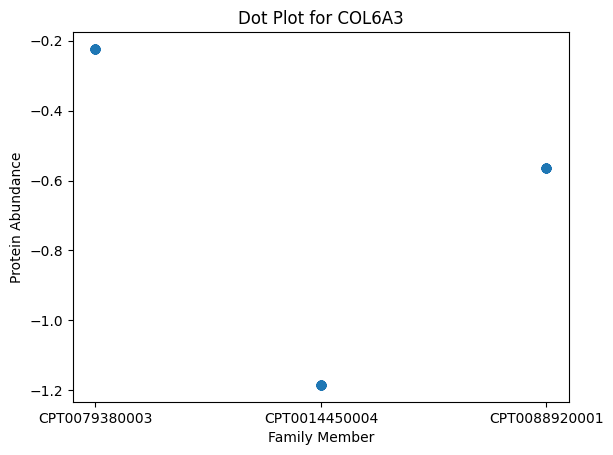

In [25]:
import matplotlib.pyplot as plt

######### Plot protein abundance per person for a single gene#########
mom = 'CPT0088920001'
dad = 'CPT0079380003'
child = 'CPT0014450004'
gene =  'COL6A3'

# Filter the data for the given gene and family members
filtered_data = df[(df['gene_name'] == gene) & (df['sample'].isin([mom, dad, child]))]

# Create a dot plot
plt.scatter(filtered_data['sample'], filtered_data['value'])
plt.xlabel('Family Member')
plt.ylabel('Protein Abundance')
plt.title(f'Dot Plot for {gene}')
plt.show()

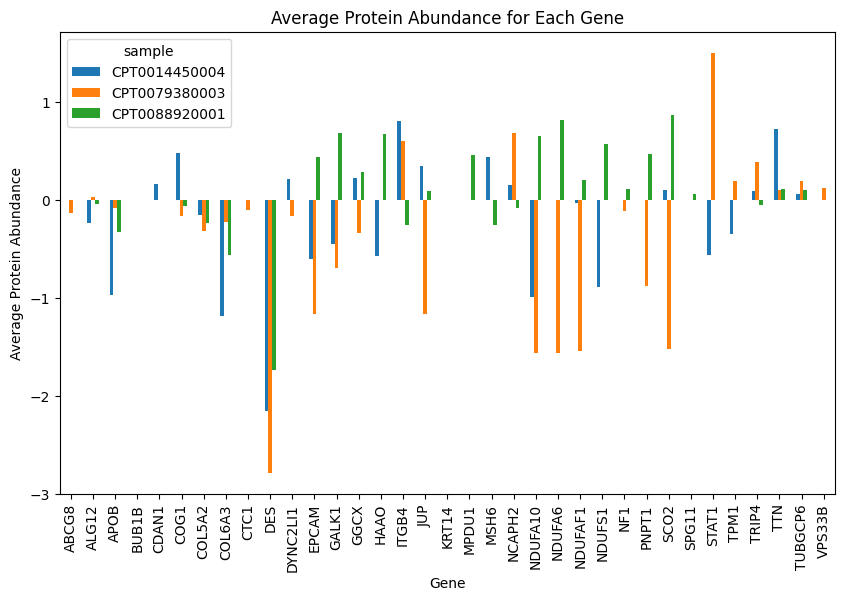

In [26]:
######### Plot protein abundance per person for all genes#########
grouped_data = df[df['sample'].isin([mom, dad, child])].groupby(['gene_name', 'sample'])['value'].mean()

# Create a bar plot
grouped_data.unstack().plot(kind='bar', figsize=(10, 6))
plt.xlabel('Gene')
plt.ylabel('Average Protein Abundance')
plt.title('Average Protein Abundance for Each Gene')
plt.show()

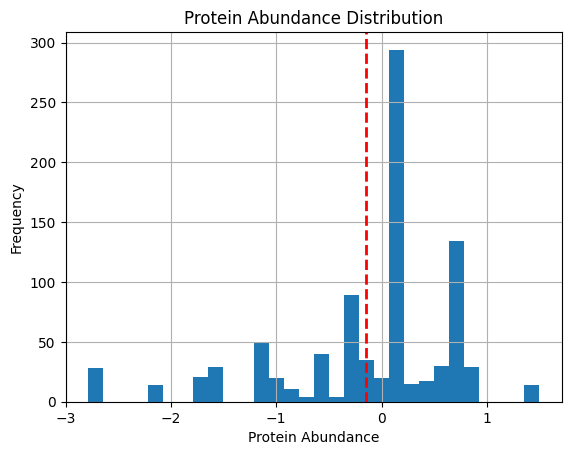

In [27]:
######### Plot average protein abundance #########

average_abundance = df['value'].mean()

# Plot a histogram for different abundances
df['value'].hist(bins=30)
plt.axvline(average_abundance, color='r', linestyle='dashed', linewidth=2)
plt.xlabel('Protein Abundance')
plt.ylabel('Frequency')
plt.title('Protein Abundance Distribution')
plt.show()

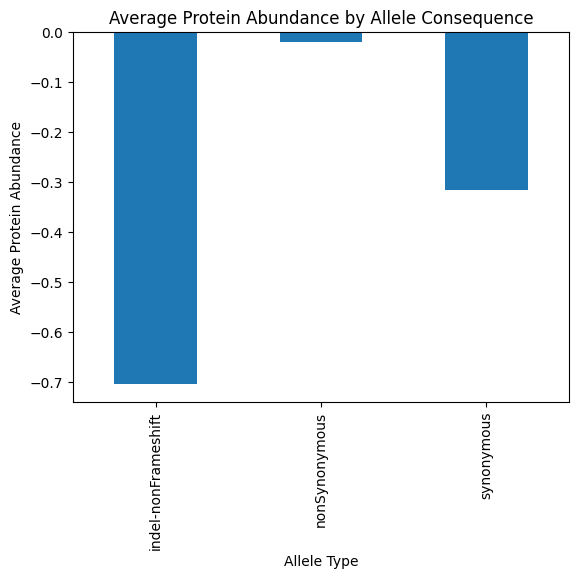

In [28]:
######### Plot protein abundance for a single mutational consequence #########

allele_abundance = df.groupby('exonic_allele_function')['value'].mean()

# Create a bar plot
allele_abundance.plot(kind='bar')
plt.xlabel('Allele Type')
plt.ylabel('Average Protein Abundance')
plt.title('Average Protein Abundance by Allele Consequence')
plt.show()

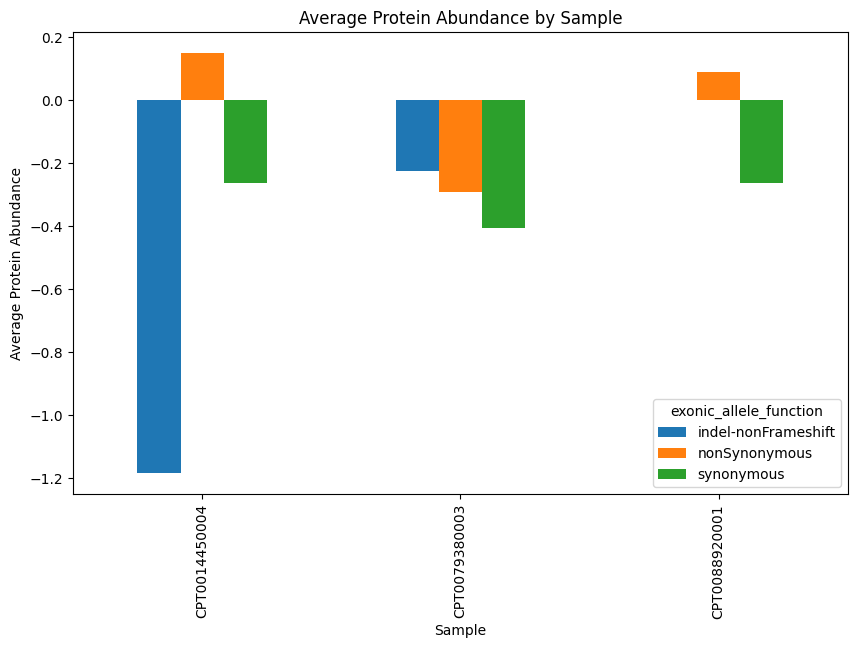

In [12]:
######### Plot protein abundance per person per mutational consequence #########

grouped_data = df[df['sample'].isin([mom, dad, child])].groupby(['sample','exonic_allele_function'])['value'].mean()

grouped_data.unstack().plot(kind='bar', figsize=(10, 6))
plt.xlabel('Sample')
plt.ylabel('Average Protein Abundance')
plt.title('Average Protein Abundance by Sample')
plt.show()

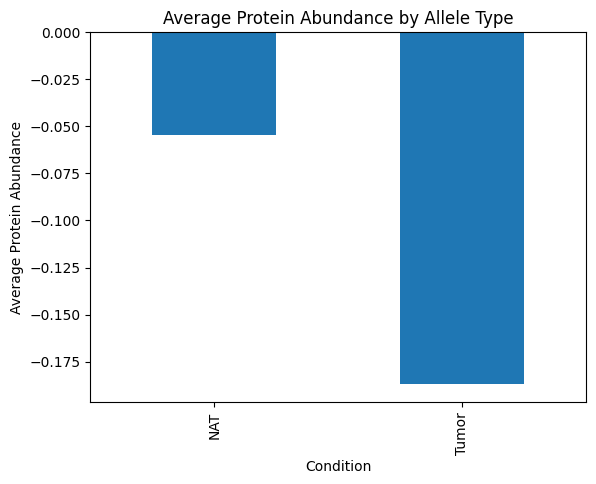

In [13]:
######### Plot average protein abundance per sample category #########

allele_abundance = df.groupby('condition')['value'].mean()

# Create a bar plot
allele_abundance.plot(kind='bar')
plt.xlabel('Condition')
plt.ylabel('Average Protein Abundance')
plt.title('Average Protein Abundance by Allele Type')
plt.show()